## Profil des visiteurs d'un site web

## ⚙️ Régression logistique, algorithme de scoring et saisonnalité

### ➡️ Dataset et librairies

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv("Data/daily-website-visitors_S13.csv", sep = ",")

# Nettoyage des colonnes numériques (les virgules)
cols_to_clean = ["Page.Loads", "Unique.Visits", "First.Time.Visits", "Returning.Visits"]
for col in cols_to_clean:
    data[col] = data[col].astype(str).str.replace(",", "").astype(int)

# Conversion de la date
data["Date"] = pd.to_datetime(data["Date"])

# Vérification
data.head()

,Row,Day,Day.Of.Week,Date,Page.Loads,Unique.Visits,First.Time.Visits,Returning.Visits
0,1,Sunday,1,2014-09-14,2146,1582,1430,152
1,2,Monday,2,2014-09-15,3621,2528,2297,231
2,3,Tuesday,3,2014-09-16,3698,2630,2352,278
3,4,Wednesday,4,2014-09-17,3667,2614,2327,287
4,5,Thursday,5,2014-09-18,3316,2366,2130,236


### ➡️ Analyse de la saisonnalité

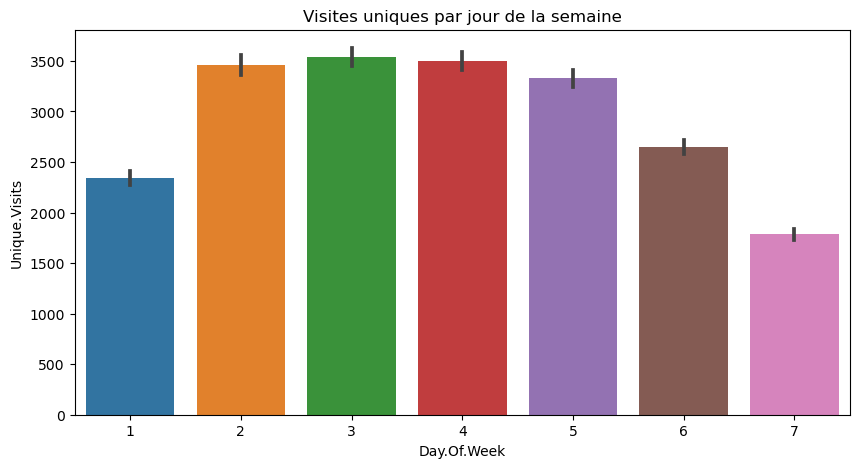

In [8]:
# Visite par jour de la semaine

plt.figure(figsize=(10,5))
sns.barplot(data=data, x="Day.Of.Week", y="Unique.Visits")
plt.title("Visites uniques par jour de la semaine")
plt.show()

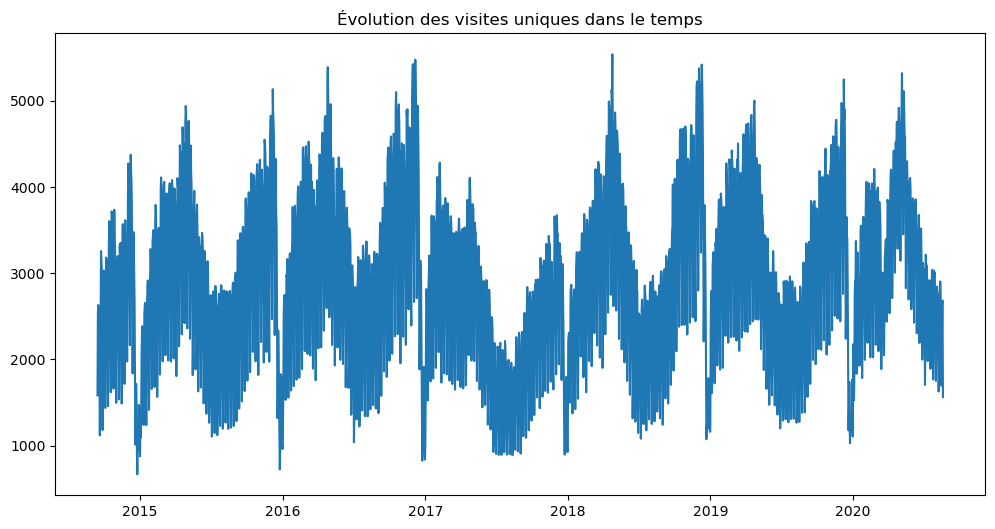

In [9]:
# Séries temporelles

plt.figure(figsize=(12,6))
plt.plot(data["Date"], data["Unique.Visits"])
plt.title("Évolution des visites uniques dans le temps")
plt.show()

### ➡️ Régression logistique

In [11]:
# variable cible

threshold = data["Unique.Visits"].quantile(0.70)
data["HighTraffic"] = (data["Unique.Visits"] >= threshold).astype(int)

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Encodage du jour de la semaine
encoder = OneHotEncoder(drop="first")
day_encoded = encoder.fit_transform(data[["Day.Of.Week"]]).toarray()

# Features
X = np.concatenate([day_encoded, data[cols_to_clean]], axis=1)
y = data["HighTraffic"]

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modèle
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Score
model.score(X_test, y_test)

c:\Users\hp\.conda\Lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


0.9953917050691244

### ➡️ Segmentation des visiteurs 

In [13]:
data["VisitorScore"] = (
    data["Unique.Visits"] * 0.5 +
    data["First.Time.Visits"] * 0.3 +
    data["Returning.Visits"] * 0.2
)

data[["Date", "VisitorScore"]].head()

,Date,VisitorScore
0,2014-09-14,1250.4
1,2014-09-15,1999.3
2,2014-09-16,2076.2
3,2014-09-17,2062.5
4,2014-09-18,1869.2


### ➡️ Visualisation

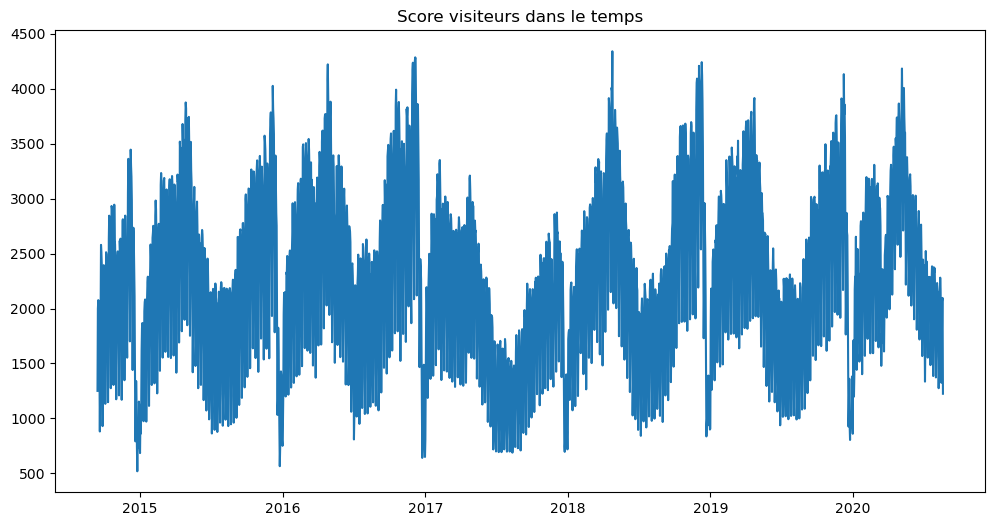

In [14]:
plt.figure(figsize=(12,6))
plt.plot(data["Date"], data["VisitorScore"])
plt.title("Score visiteurs dans le temps")
plt.show()

### ➡️ Résumé

L’analyse du dataset daily_website_visitors met en évidence plusieurs tendances fortes qui permettent de mieux comprendre le comportement des visiteurs et la dynamique globale du trafic Web du site en question.

1. Un scoring cohérent avec la dynamique temporelle:
Le score que j'ai obtenu  (basé sur les visites uniques, premières visites et visites de retour) suit pratiquement la même courbe que la série temporelle des visites. Donc un scoring bien calibré et il reflète fidèlement l’intensité du trafic et la qualité des visites.
Autrement dit, les jours où le trafic est élevé sont aussi ceux où la valeur des visiteurs est la plus forte.

2. Une régression logistique extrêmement performante:
Le modèle de régression logistique atteint un score de 0,9953, ce qui est exceptionnel.
Cela signifie que les variables explicatives (jour de la semaine, visites uniques, premières visites, etc.) permettent de prédire avec une très grande précision les jours de forte affluence.
Ce niveau de performance indique que : Le comportement des visiteurs est hautement prévisible, les patterns de trafic sont stables et répétitifs et les variables du dataset sont très informatives.

3. Les jours les plus performants de la semaine:
Le classement des jours en termes de visites montre une hiérarchie nette :
Mercredi  
Jeudi  
Mardi  
Vendredi  
Samedi  
Lundi  
Dimanche

Donc le trafic est maximal en milieu de semaine, probablement lié à une activité professionnelle plus intense. Le week-end, surtout le dimanche, est le jour le plus faible, ce qui correspond à une baisse d’activité numérique classique.

4. Une saisonnalité très marquée et répétitive:
La série temporelle montre une tendance très nette. Elle revèle un trafic élevé en début d'année, une baisse progressive en milieu d'année et vers la fin d'année, une remontée du trafic.
Cette dynamique peut s’expliquer par les périodes de reprise d’activité (janvier), les creux saisonniers (vacances, été) et les pics de fin d’année (retour au travail, campagnes marketing, événements)

Conclusion : Le trafic Web du site étudié est fortement structuré, prévisible et influencé par des cycles hebdomadaires et annuels. Les modèles statistiques et les visualisations montrent que les visiteurs ont des comportements réguliers, les jours de la semaine jouent un rôle majeur et la saisonnalité est stable d’une année à l’autre.